# Notebook 02 - Gorsellestirme

Bu notebook, enerji perakende case study icin tuketim, tahsilat ve odeme zamanlamasi verilerini gorsellestirir.

## Icindekiler

1. Kurulum ve Veri Yukleme
2. Veri Hazirligi
3. Dagilim Grafikleri
4. Zaman Serisi Grafikleri
5. Karsilastirma Grafikleri
6. Odeme Zamanlamasi Grafikleri
7. Iliski Analizi
8. Genel Degerlendirme


## 1. Kurulum ve Veri Yukleme

Gerekli kutuphaneler yuklenir, veri dosyasi ve grafik cikti klasoru tanimlanir.


In [25]:
from pathlib import Path
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["font.size"] = 10

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

DATA_PATH = PROJECT_ROOT / "data" / "elektrik_veri.xlsx"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def wrap_labels(labels, width=22):
    return [chr(10).join(textwrap.wrap(str(label), width=width)) for label in labels]

def add_bar_labels(ax, values=None, fmt="{:.1f}%", fontsize=8):
    if values is None:
        ax.bar_label(ax.containers[0], padding=2, fontsize=fontsize)
    else:
        ax.bar_label(ax.containers[0], labels=[fmt.format(v) for v in values], padding=2, fontsize=fontsize)

print("Veri dosyasi:", DATA_PATH)
print("Grafik klasoru:", FIGURES_DIR)


Veri dosyasi: d:\AÇV-CASE2\case_study_02\data\elektrik_veri.xlsx
Grafik klasoru: d:\AÇV-CASE2\case_study_02\outputs\figures


In [26]:
xls = pd.ExcelFile(DATA_PATH)
print("Excel sayfalari:")
print(xls.sheet_names)


Excel sayfalari:
['Tahsilat', 'Tahsilat 1', 'Tahakkuk', 'Tahakkuk 1', 'Tahakkuk 2']


In [27]:
df_tahsilat = pd.read_excel(xls, sheet_name="Tahsilat")
df_tahsilat_1 = pd.read_excel(xls, sheet_name="Tahsilat 1")

df_hamamozu = pd.read_excel(xls, sheet_name="Tahakkuk")
df_gumushacikoy = pd.read_excel(xls, sheet_name="Tahakkuk 1")
df_goynucek = pd.read_excel(xls, sheet_name="Tahakkuk 2")

tahakkuk_dfs = {
    "Hamamozu": df_hamamozu,
    "Gumushacikoy": df_gumushacikoy,
    "Goynucek": df_goynucek,
}

for name, df in {"Tahsilat": df_tahsilat, "Tahsilat 1": df_tahsilat_1, **tahakkuk_dfs}.items():
    print(f"{name:<15}: {df.shape}")


Tahsilat       : (636993, 9)
Tahsilat 1     : (917632, 22)
Hamamozu       : (124818, 10)
Gumushacikoy   : (765657, 10)
Goynucek       : (295223, 10)


## 2. Veri Hazirligi

Tuketim, tahsilat ve odeme zamanlamasi grafiklerinde kullanilacak ortak alanlar hazirlanir.


In [28]:
df_tahakkuk_all = pd.concat(tahakkuk_dfs.values(), ignore_index=True)
hesap_sinifi_col = df_tahakkuk_all.columns[8]

df_tahakkuk_all["mali_yil_donem"] = pd.to_datetime(df_tahakkuk_all["mali_yil_donem"], errors="coerce")
df_tahakkuk_all["donem"] = df_tahakkuk_all["mali_yil_donem"].dt.to_period("M").dt.to_timestamp()
df_tahakkuk_all["yil"] = df_tahakkuk_all["donem"].dt.year
df_tahakkuk_all["ay"] = df_tahakkuk_all["donem"].dt.month
df_tahakkuk_all["ilce"] = df_tahakkuk_all["ilce"].str.strip()
df_tahakkuk_all[hesap_sinifi_col] = df_tahakkuk_all[hesap_sinifi_col].str.strip()

# Tahsilat odeme tutari ve tarih hazirligi.
tahsilat_ilce_col = df_tahsilat.columns[2]
tahsilat_sube_col = df_tahsilat.columns[0]
tahsilat_tarih_col = df_tahsilat.columns[4]
odeme_turu_cols = df_tahsilat.columns[5:9].tolist()

df_tahsilat_clean = df_tahsilat.copy()
df_tahsilat_clean[odeme_turu_cols] = df_tahsilat_clean[odeme_turu_cols].fillna(0)
df_tahsilat_clean[tahsilat_tarih_col] = pd.to_datetime(df_tahsilat_clean[tahsilat_tarih_col], errors="coerce")
df_tahsilat_clean["donem"] = df_tahsilat_clean[tahsilat_tarih_col].dt.to_period("M").dt.to_timestamp()
df_tahsilat_clean["toplam_tahsilat"] = df_tahsilat_clean[odeme_turu_cols].sum(axis=1)

# Tahsilat 1 donem metnini tarihe cevirme.
ay_haritasi = {
    "OCK": 1, "SBT": 2, "SUB": 2, "MAR": 3, "NIS": 4, "MAY": 5,
    "HAZ": 6, "TEM": 7, "AGU": 8, "EYL": 9, "EKM": 10,
    "KAS": 11, "KSM": 11, "ARA": 12, "ARL": 12,
}

def sade_turkce(seri):
    return (
        seri.astype("string").str.strip().str.upper()
        .str.replace(chr(350), "S", regex=False)
        .str.replace(chr(286), "G", regex=False)
        .str.replace(chr(220), "U", regex=False)
        .str.replace(chr(214), "O", regex=False)
        .str.replace(chr(304), "I", regex=False)
        .str.replace(chr(199), "C", regex=False)
    )

def donem_to_datetime(seri):
    parcalar = sade_turkce(seri).str.split(expand=True)
    ay = parcalar[0].map(ay_haritasi)
    yil = pd.to_numeric(parcalar[1], errors="coerce")
    return pd.to_datetime({"year": yil, "month": ay, "day": 1}, errors="coerce")

df_tahsilat_1_clean = df_tahsilat_1.copy()
tahsilat1_donem_col = df_tahsilat_1_clean.columns[0]
tahsilat1_ilce_col = df_tahsilat_1_clean.columns[2]
tahakkuk_tutar_col = df_tahsilat_1_clean.columns[5]
zamaninda_cols = df_tahsilat_1_clean.columns[6:8].tolist()
gec_cols = df_tahsilat_1_clean.columns[8:22].tolist()
odeme_zamani_cols = zamaninda_cols + gec_cols

df_tahsilat_1_clean["donem"] = donem_to_datetime(df_tahsilat_1_clean[tahsilat1_donem_col])
df_tahsilat_1_clean["zamaninda_kayit"] = df_tahsilat_1_clean[zamaninda_cols].notna().any(axis=1)
df_tahsilat_1_clean["gec_kayit"] = df_tahsilat_1_clean[gec_cols].notna().any(axis=1)
df_tahsilat_1_clean[odeme_zamani_cols] = df_tahsilat_1_clean[odeme_zamani_cols].fillna(0)
df_tahsilat_1_clean["zamaninda_tutar"] = df_tahsilat_1_clean[zamaninda_cols].sum(axis=1)
df_tahsilat_1_clean["gec_tutar"] = df_tahsilat_1_clean[gec_cols].sum(axis=1)

print("Birlesik tahakkuk veri boyutu:", df_tahakkuk_all.shape)
print("Tahakkuk donem eksik:", df_tahakkuk_all["donem"].isna().sum())
print("Tahsilat 1 donem eksik:", df_tahsilat_1_clean["donem"].isna().sum())


Birlesik tahakkuk veri boyutu: (1185698, 13)
Tahakkuk donem eksik: 0
Tahsilat 1 donem eksik: 0


## 3. Dagilim Grafikleri

Bu bolumde hesap sinifi dagilimi, kWh tuketim dagilimi ve ilce bazinda musteri sayisi gorsellestirilir.


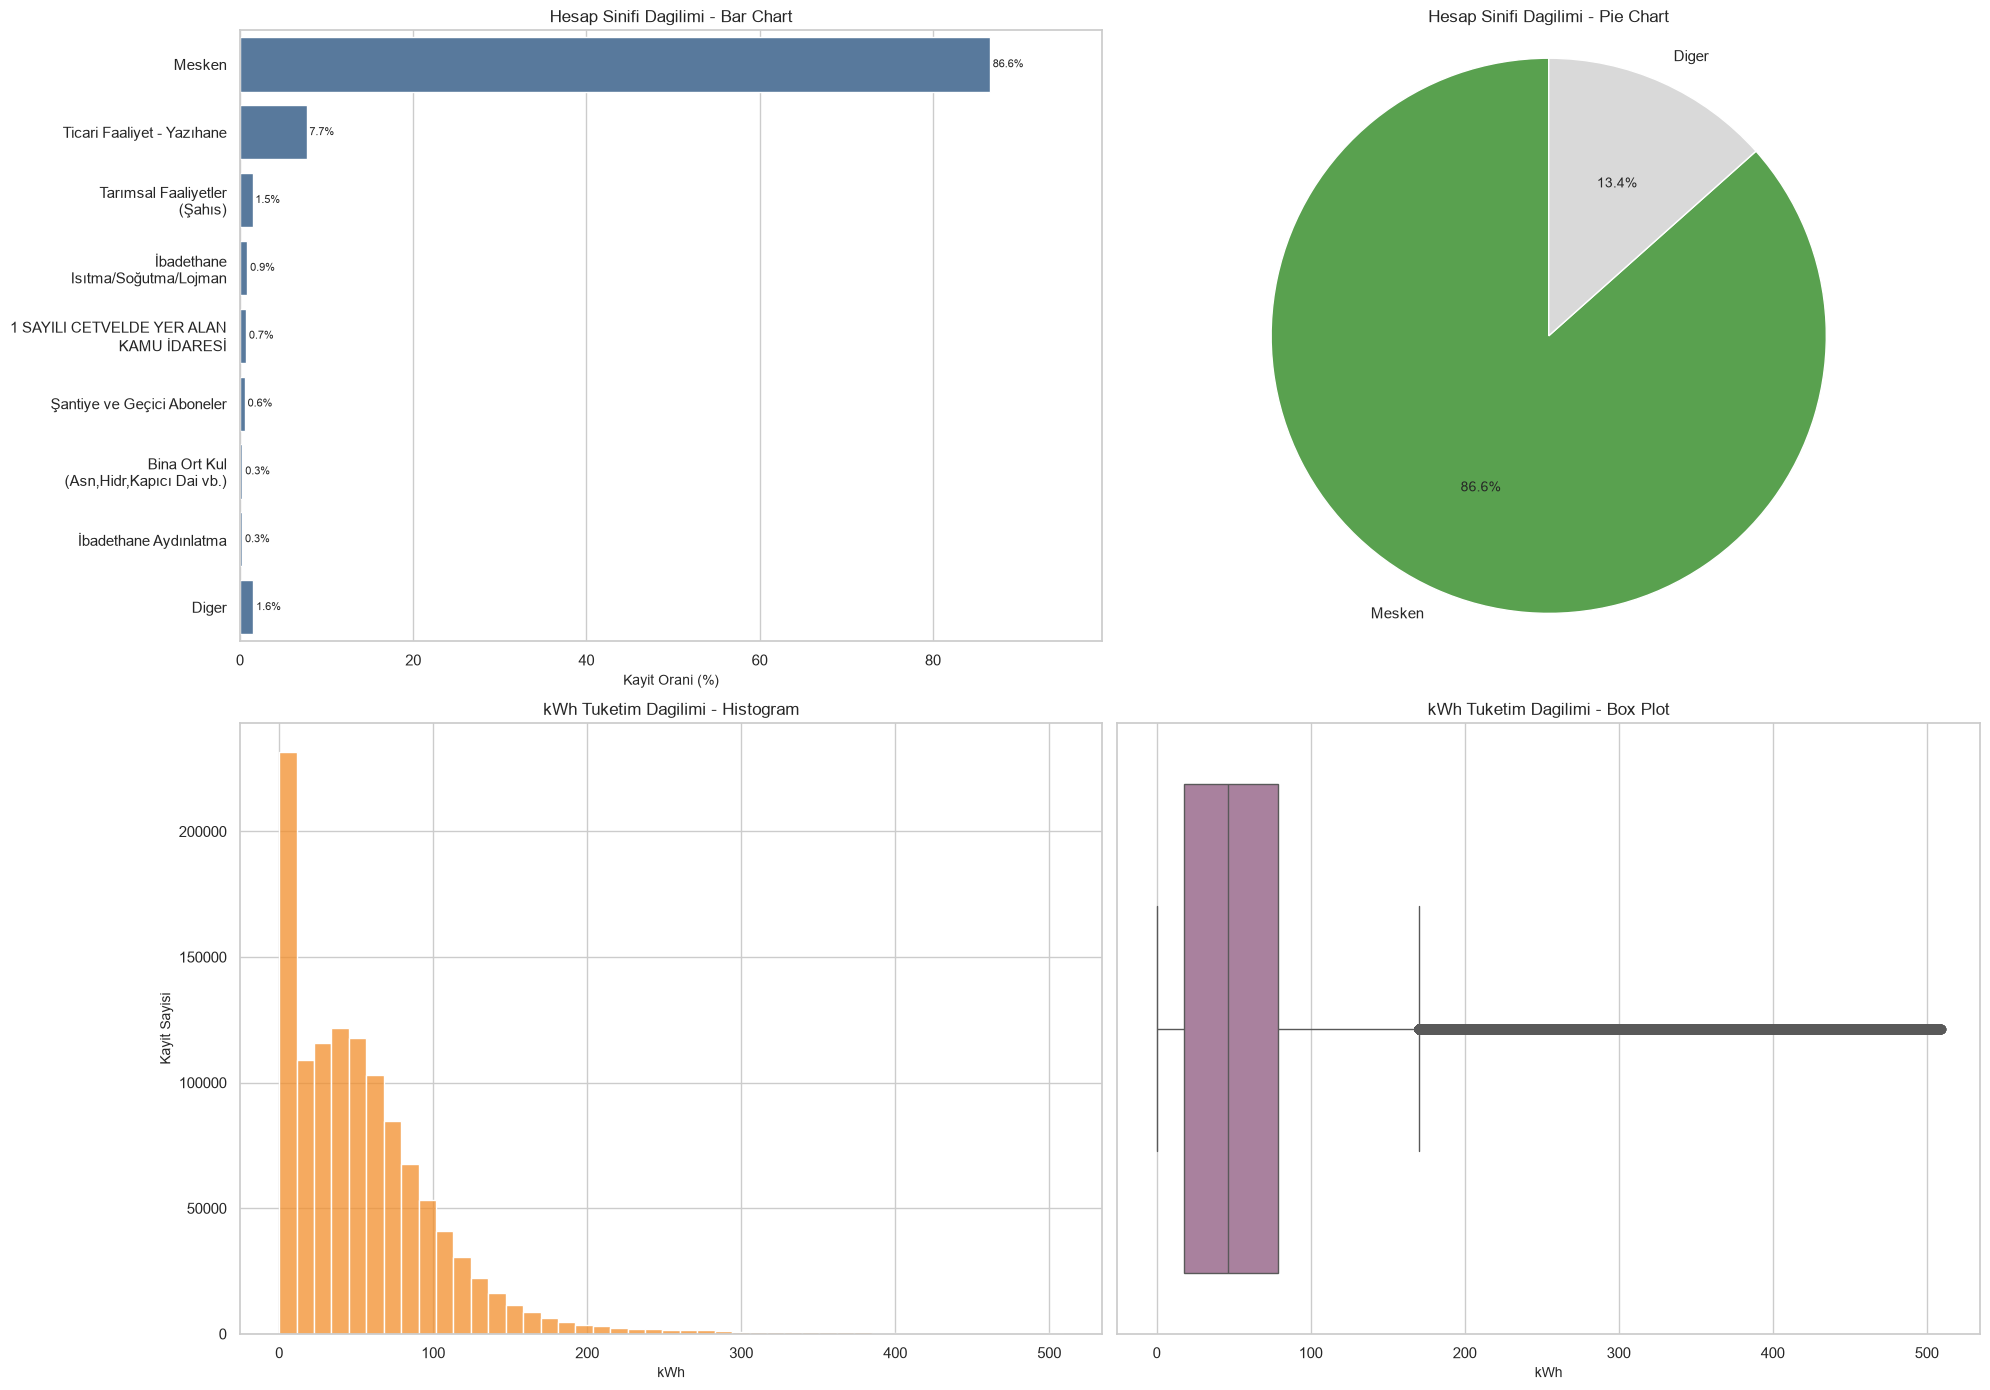

In [29]:
def top_with_other(series, top_n=8):
    counts = series.value_counts()
    top = counts.head(top_n)
    other = counts.iloc[top_n:].sum()
    if other > 0:
        top.loc["Diger"] = other
    return top

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Hesap sinifi dagilimi - bar chart.
hesap_counts = top_with_other(df_tahakkuk_all[hesap_sinifi_col], top_n=8)
hesap_pct = hesap_counts / hesap_counts.sum() * 100
sns.barplot(x=hesap_pct.values, y=wrap_labels(hesap_pct.index, 26), ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("Hesap Sinifi Dagilimi - Bar Chart")
axes[0, 0].set_xlabel("Kayit Orani (%)")
axes[0, 0].set_ylabel("")
axes[0, 0].set_xlim(0, max(hesap_pct.max() * 1.15, 5))
add_bar_labels(axes[0, 0], hesap_pct.values)

# Hesap sinifi dagilimi - pie chart, okunabilirlik icin Mesken / Diger.
mesken_count = (df_tahakkuk_all[hesap_sinifi_col] == "Mesken").sum()
pie_counts = pd.Series({"Mesken": mesken_count, "Diger": len(df_tahakkuk_all) - mesken_count})
axes[0, 1].pie(pie_counts.values, labels=pie_counts.index, autopct="%1.1f%%", startangle=90, colors=["#59A14F", "#D9D9D9"])
axes[0, 1].set_title("Hesap Sinifi Dagilimi - Pie Chart")
axes[0, 1].axis("equal")

# kWh histogram.
plot_limit = df_tahakkuk_all.loc[df_tahakkuk_all["kwh"] >= 0, "kwh"].quantile(0.99)
plot_kwh = df_tahakkuk_all.loc[(df_tahakkuk_all["kwh"] >= 0) & (df_tahakkuk_all["kwh"] <= plot_limit), "kwh"]
sns.histplot(plot_kwh, bins=45, ax=axes[1, 0], color="#F28E2B")
axes[1, 0].set_title("kWh Tuketim Dagilimi - Histogram")
axes[1, 0].set_xlabel("kWh")
axes[1, 0].set_ylabel("Kayit Sayisi")

# kWh box plot.
sns.boxplot(x=plot_kwh, ax=axes[1, 1], color="#B07AA1")
axes[1, 1].set_title("kWh Tuketim Dagilimi - Box Plot")
axes[1, 1].set_xlabel("kWh")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "dagilim_grafikleri_panel.png", dpi=150, bbox_inches="tight")
plt.show()


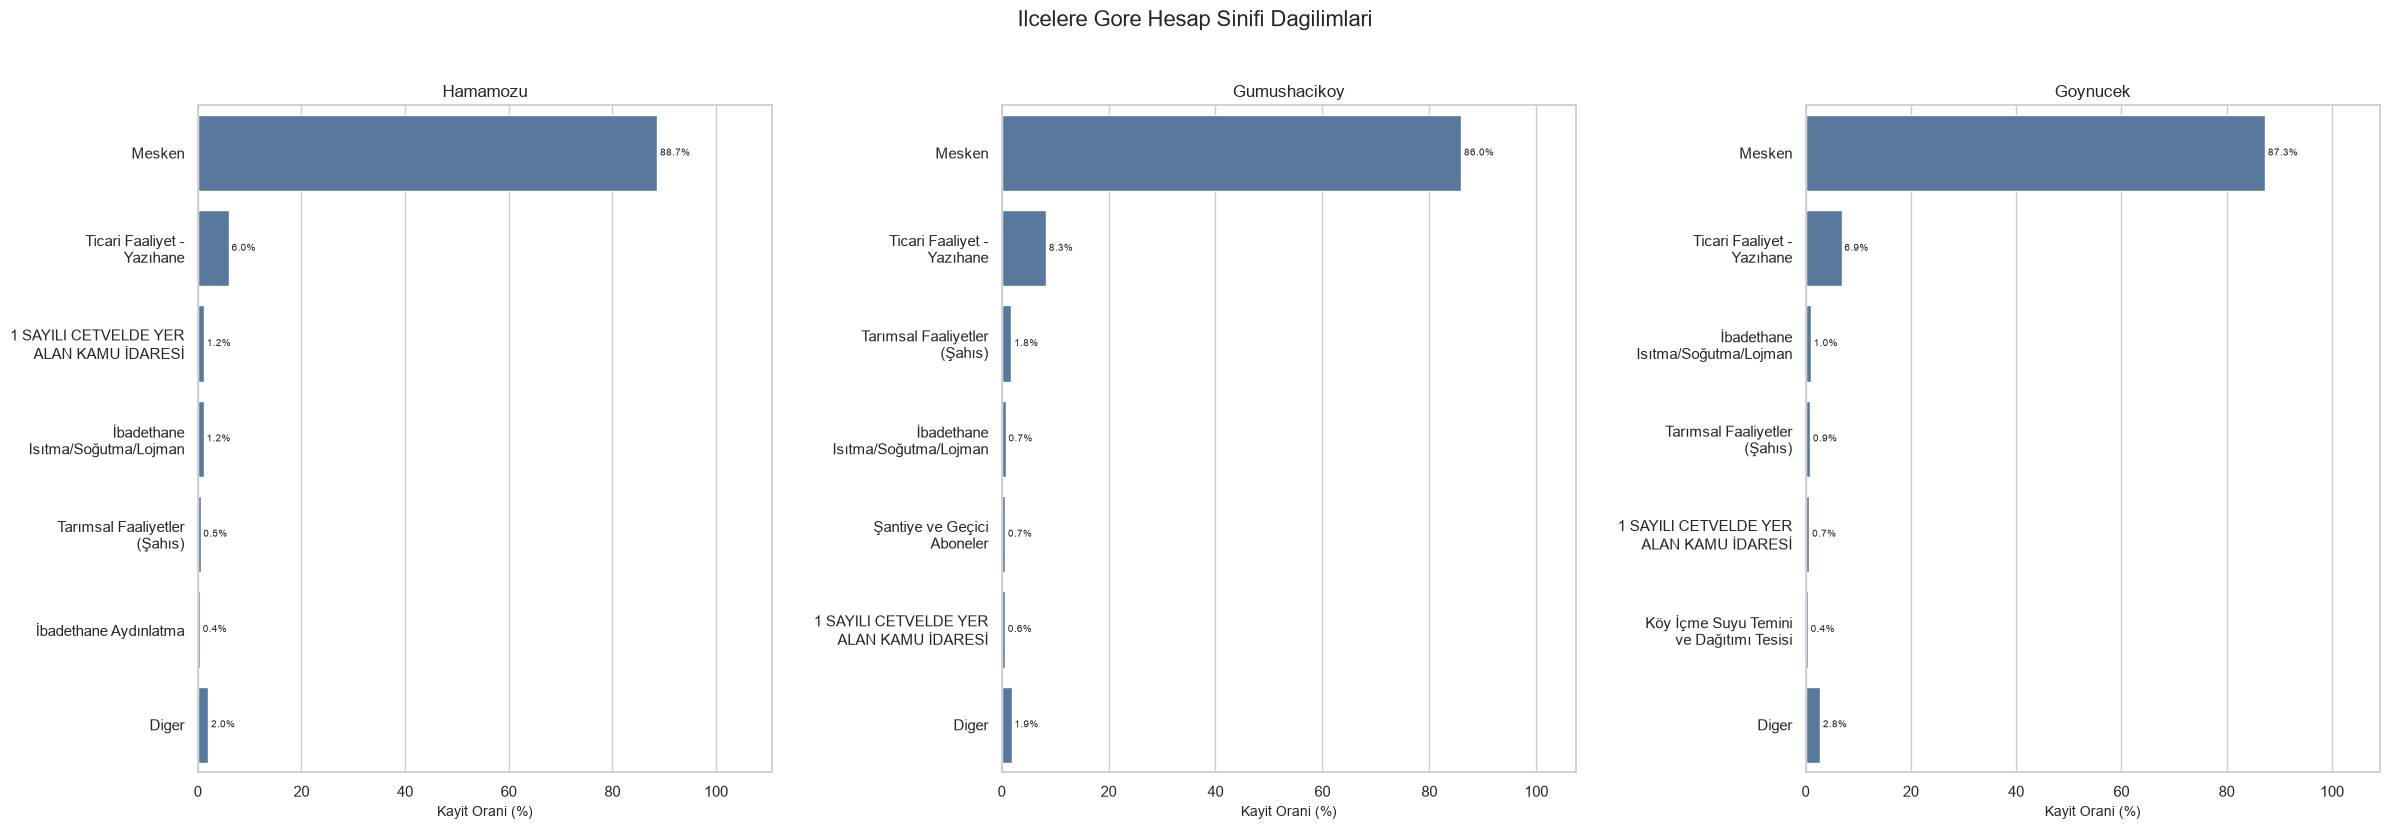

In [30]:
# Case isterine uygun: 3 ilcenin hesap sinifi dagilimlari yan yana subplot.
fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharex=False)

for ax, (name, df) in zip(axes, tahakkuk_dfs.items()):
    counts = top_with_other(df[df.columns[8]].str.strip(), top_n=6)
    pct = counts / counts.sum() * 100
    sns.barplot(x=pct.values, y=wrap_labels(pct.index, 22), ax=ax, color="#4C78A8")
    ax.set_title(name)
    ax.set_xlabel("Kayit Orani (%)")
    ax.set_ylabel("")
    ax.set_xlim(0, max(pct.max() * 1.25, 5))
    add_bar_labels(ax, pct.values, fontsize=7)

fig.suptitle("Ilcelere Gore Hesap Sinifi Dagilimlari", fontsize=16, y=1.03)
plt.tight_layout(w_pad=3)
plt.savefig(FIGURES_DIR / "hesap_sinifi_dagilimlari_subplot.png", dpi=150, bbox_inches="tight")
plt.show()


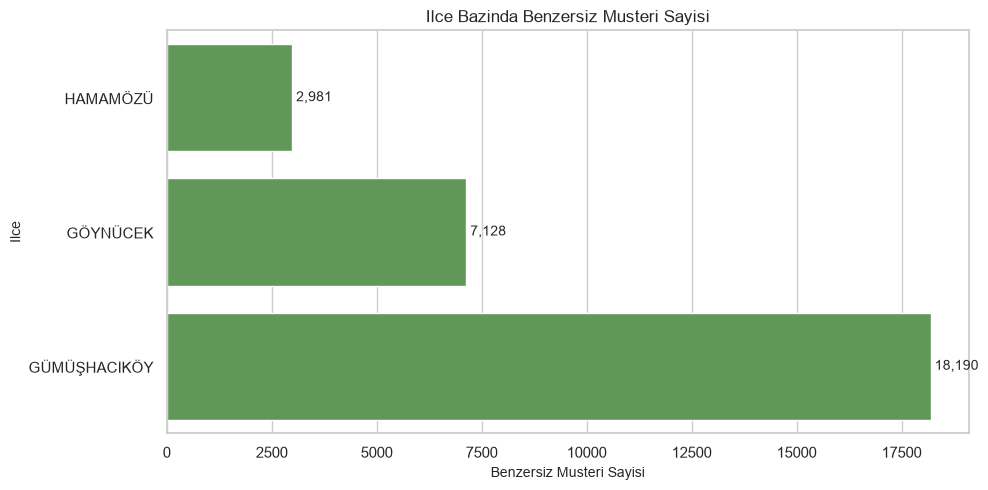

In [31]:
# Ilce bazinda benzersiz musteri sayisi - horizontal bar.
musteri_sayilari = (
    df_tahakkuk_all.groupby("ilce")["sozlesme_hesap_no"]
    .nunique()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=musteri_sayilari.values, y=musteri_sayilari.index, ax=ax, color="#59A14F")
ax.set_title("Ilce Bazinda Benzersiz Musteri Sayisi")
ax.set_xlabel("Benzersiz Musteri Sayisi")
ax.set_ylabel("Ilce")
ax.bar_label(ax.containers[0], fmt="{:,.0f}", padding=3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ilce_musteri_sayisi_horizontal_bar.png", dpi=150, bbox_inches="tight")
plt.show()


### Dagilim Yorumu

- Hesap sinifi dagiliminda Mesken sinifi acik ara baskindir. Bu durum veri setindeki tuketim kayitlarinin buyuk bolumunun konut abonelerinden geldigini gosterir.
- Mesken disindaki hesap siniflari kayit sayisi olarak daha kucuk gorunse de, Notebook 01'de goruldugu gibi Sanayi, Lisansiz Ureticiler, Aritma Tesisleri ve Karayollari Aydinlatma gibi siniflarda kayit basina tuketim cok daha yuksektir.
- kWh histogrami saga carpik bir dagilim gostermektedir. Kayitlarin buyuk bolumu dusuk ve orta tuketim araliginda toplanirken az sayida cok yuksek tuketim degeri bulunmaktadir.
- Box plot da bu carpikligi destekler: ust tarafta belirgin aykiri degerler vardir. Bu degerler otomatik olarak silinmemis, cunku bazi hesap siniflari dogal olarak yuksek tuketime sahiptir.
- Ilce bazinda benzersiz musteri sayisinda Gumushacikoy en yuksek hacme sahiptir. Bu nedenle ilceler toplam tuketimle karsilastirilirken musteri sayisi farki mutlaka dikkate alinmalidir.


## 4. Zaman Serisi Grafikleri

Aylik tuketim trendi, yillik karsilastirma ve tahsilat trendi birlikte incelenir.


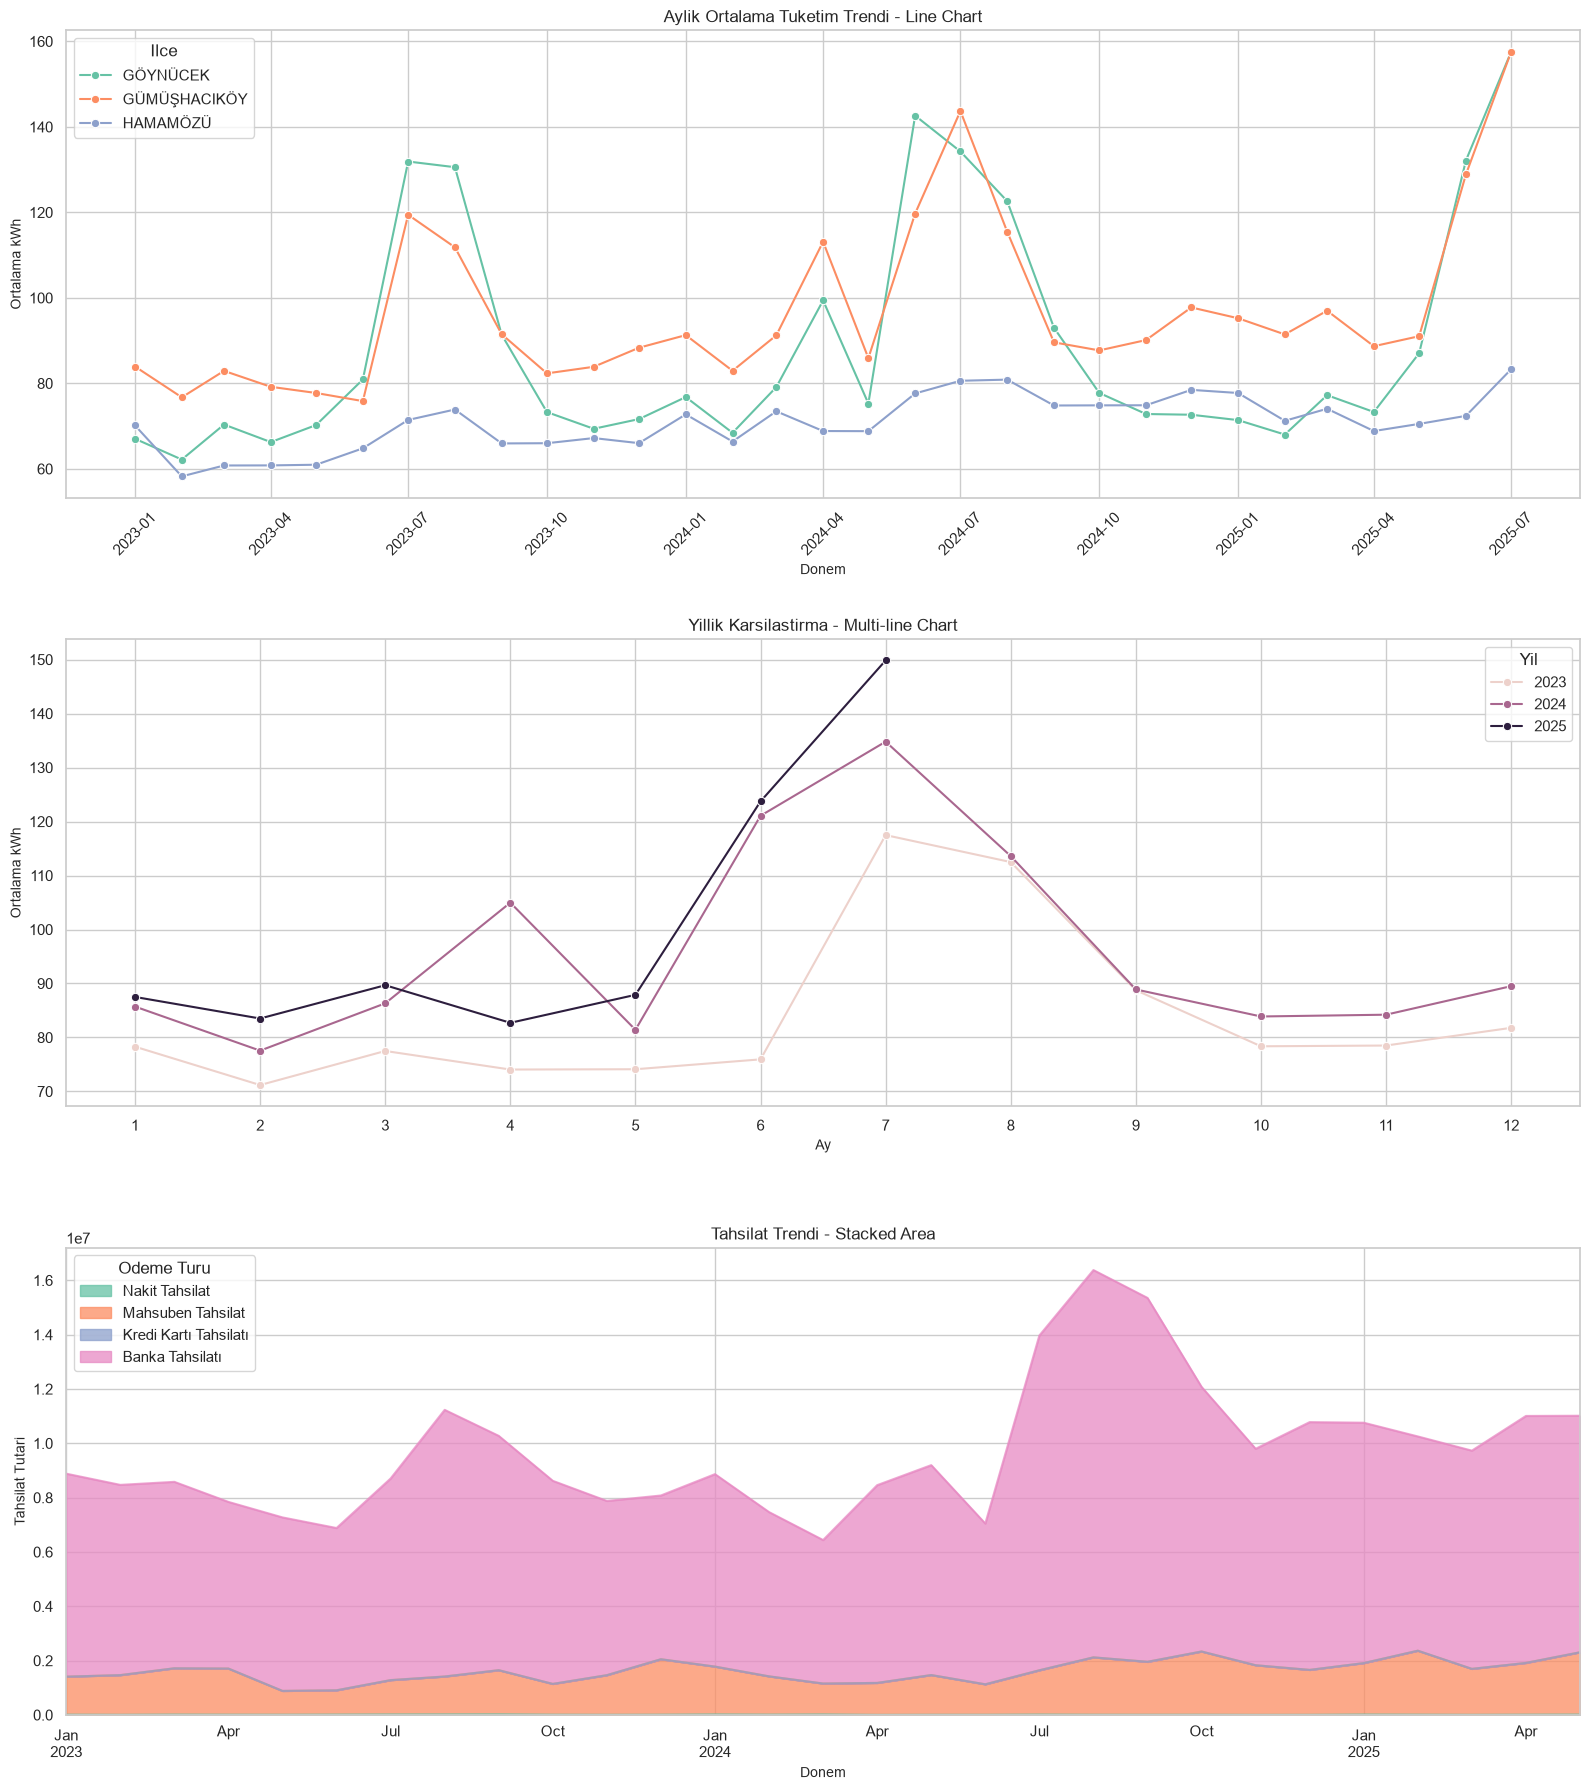

In [32]:
aylik_tuketim = (
    df_tahakkuk_all.groupby(["donem", "ilce"], as_index=False)["kwh"]
    .mean()
    .rename(columns={"kwh": "ortalama_kwh"})
)

yillik_aylik = (
    df_tahakkuk_all.groupby(["yil", "ay"], as_index=False)["kwh"]
    .mean()
    .rename(columns={"kwh": "ortalama_kwh"})
)

tahsilat_trend = (
    df_tahsilat_clean.groupby("donem")[odeme_turu_cols]
    .sum()
    .sort_index()
)

fig, axes = plt.subplots(3, 1, figsize=(16, 18))

sns.lineplot(data=aylik_tuketim, x="donem", y="ortalama_kwh", hue="ilce", marker="o", ax=axes[0])
axes[0].set_title("Aylik Ortalama Tuketim Trendi - Line Chart")
axes[0].set_xlabel("Donem")
axes[0].set_ylabel("Ortalama kWh")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Ilce")

sns.lineplot(data=yillik_aylik, x="ay", y="ortalama_kwh", hue="yil", marker="o", ax=axes[1])
axes[1].set_title("Yillik Karsilastirma - Multi-line Chart")
axes[1].set_xlabel("Ay")
axes[1].set_ylabel("Ortalama kWh")
axes[1].set_xticks(range(1, 13))
axes[1].legend(title="Yil")

tahsilat_trend.plot.area(ax=axes[2], alpha=0.75)
axes[2].set_title("Tahsilat Trendi - Stacked Area")
axes[2].set_xlabel("Donem")
axes[2].set_ylabel("Tahsilat Tutari")
axes[2].legend(title="Odeme Turu", loc="upper left")

plt.tight_layout(h_pad=3)
plt.savefig(FIGURES_DIR / "zaman_serisi_grafikleri_panel.png", dpi=150, bbox_inches="tight")
plt.show()


### Zaman Serisi Yorumu

- Aylik tuketim trendleri ilceler arasinda benzer mevsimsel hareketler oldugunu, ancak tuketim seviyelerinin ilceye gore farklastigini gosterir.
- Yaz aylarinda tuketim seviyesinin artmasi, sogutma, tarimsal faaliyetler veya donemsel kullanim etkileriyle iliskili olabilir.
- Yillik karsilastirma grafigi ayni aylarin farkli yillardaki ortalama tuketimlerini karsilastirmayi saglar. Bu grafik mevsimsellik ile yildan yila degisimi ayirmak icin kullanislidir.
- Tahsilat trendinin stacked area olarak verilmesi, toplam tahsilat hacminin zaman icinde hangi odeme turleriyle olustugunu gosterir. Banka tahsilati baskinsa, tahsilat operasyonlarinda banka kanalinin ana kanal oldugu yorumu yapilabilir.


## 5. Karsilastirma Grafikleri

Ilceler arasi tuketim, hesap sinifi x ilce matrisi ve odeme zamanlamasi stacked bar ile karsilastirilir.


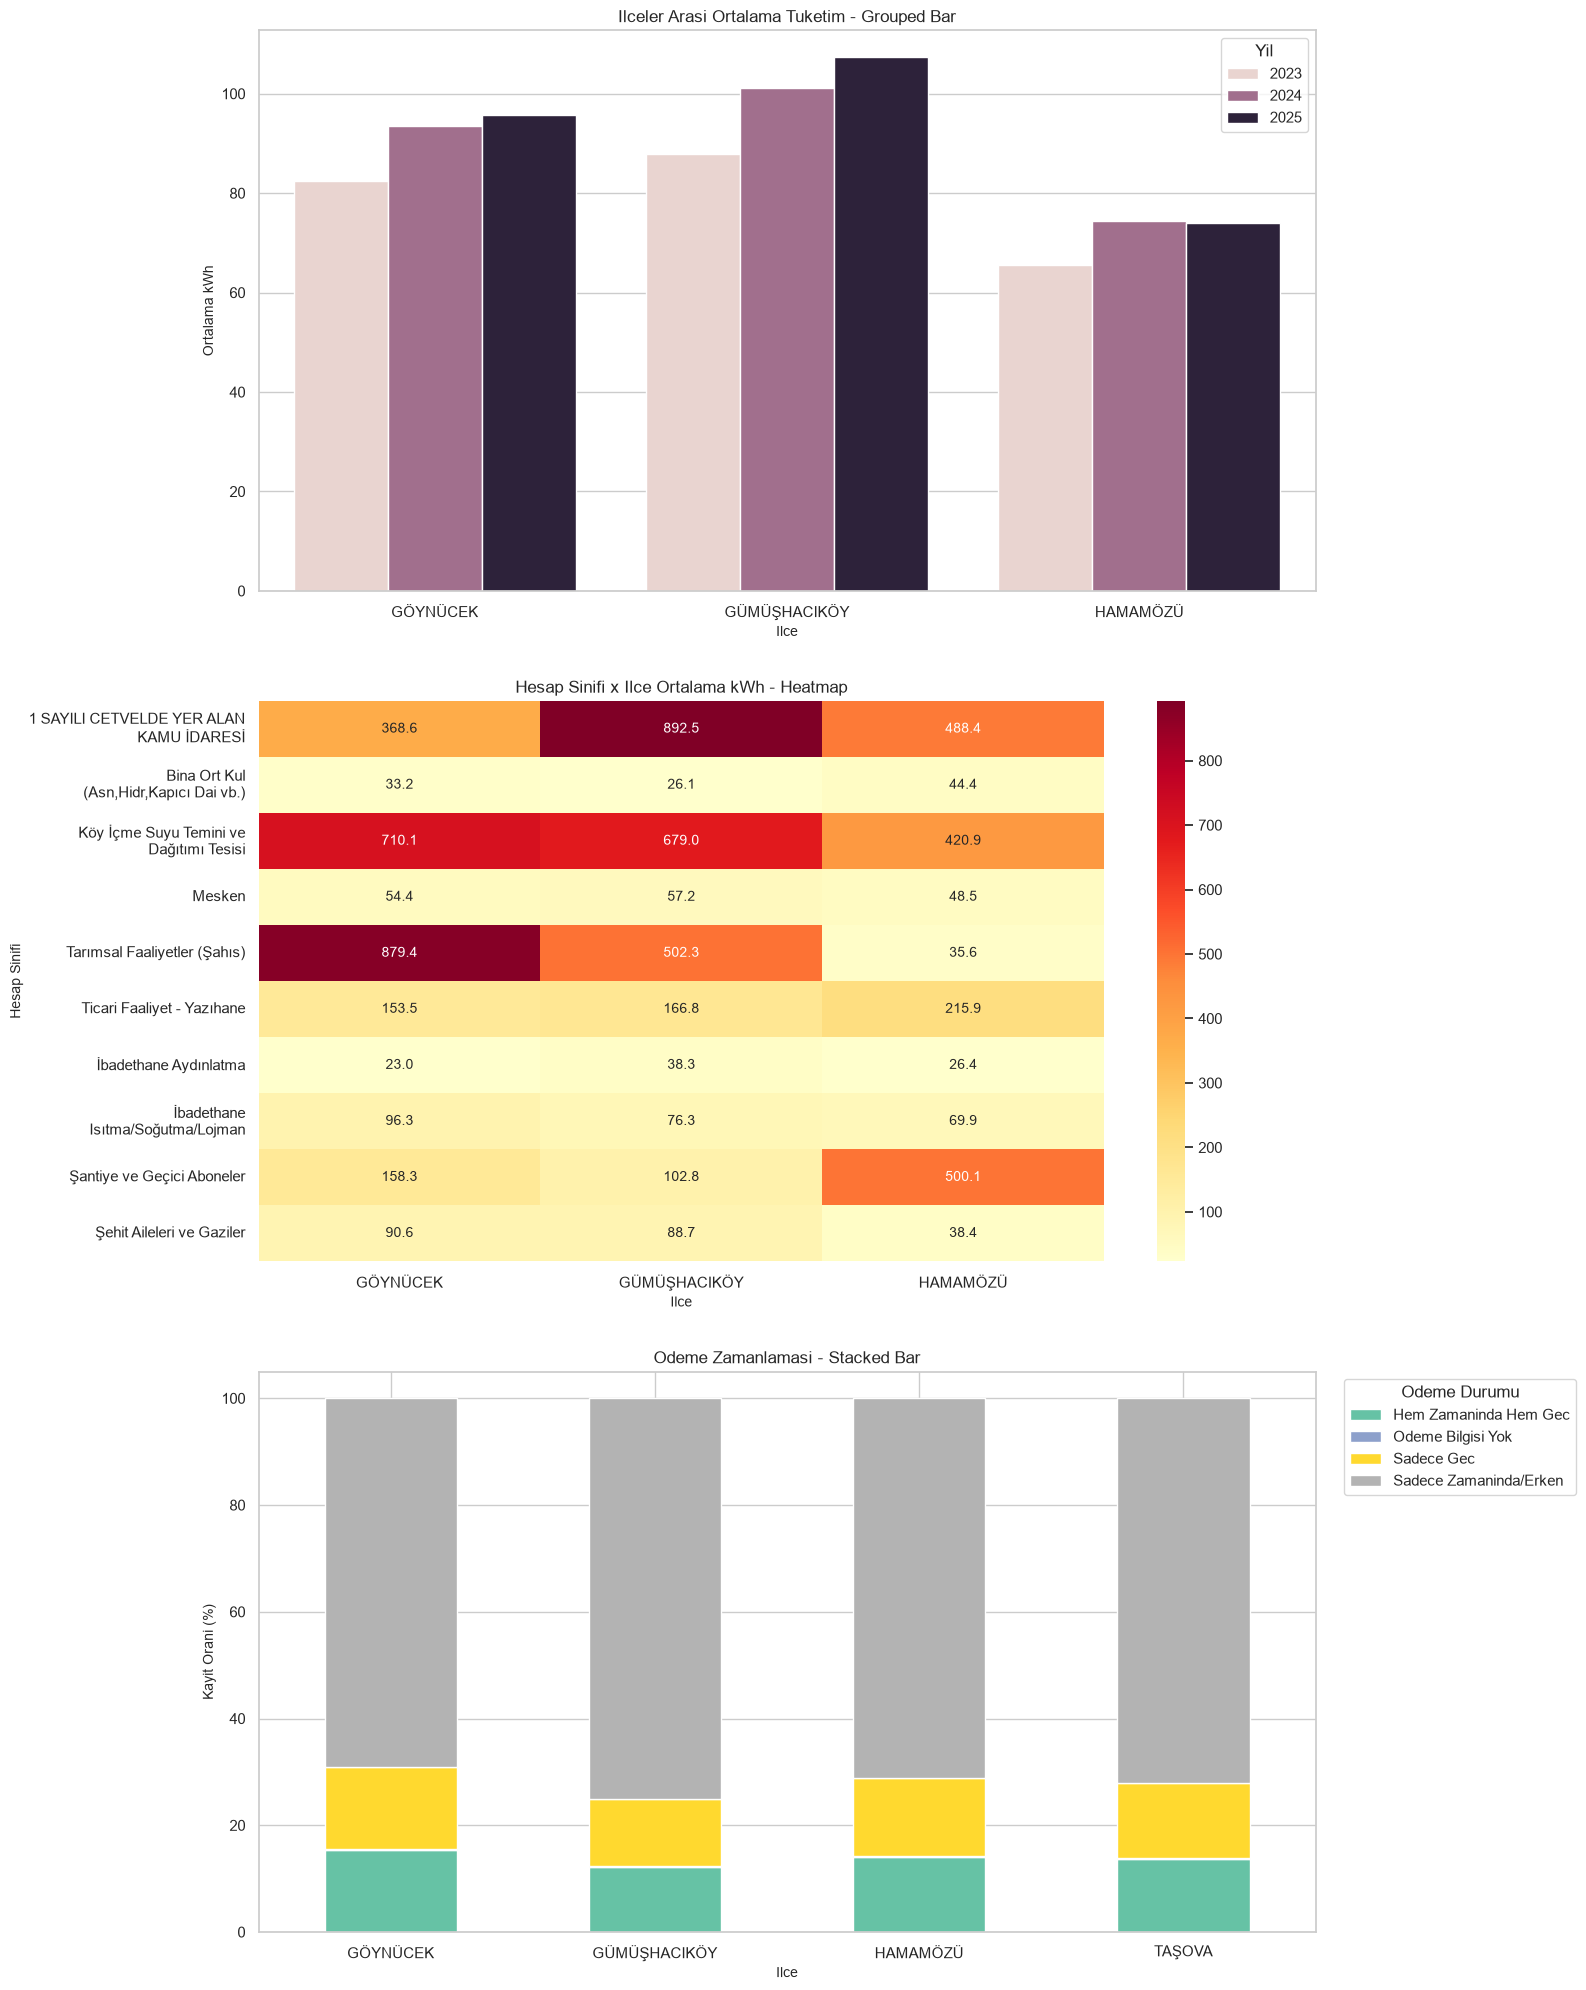

In [33]:
# Ilceler arasi tuketim - grouped bar.
ilce_yil_tuketim = (
    df_tahakkuk_all.groupby(["ilce", "yil"], as_index=False)["kwh"]
    .mean()
    .rename(columns={"kwh": "ortalama_kwh"})
)

# Hesap sinifi x ilce - heatmap. En yaygin ilk 10 hesap sinifi kullanilir.
top_hesaplar = df_tahakkuk_all[hesap_sinifi_col].value_counts().head(10).index
heatmap_data = (
    df_tahakkuk_all[df_tahakkuk_all[hesap_sinifi_col].isin(top_hesaplar)]
    .pivot_table(index=hesap_sinifi_col, columns="ilce", values="kwh", aggfunc="mean")
)

# Odeme zamanlamasi - stacked bar. Kismi odeme nedeniyle dort kategori kullanilir.
conditions = [
    df_tahsilat_1_clean["zamaninda_kayit"] & df_tahsilat_1_clean["gec_kayit"],
    df_tahsilat_1_clean["zamaninda_kayit"] & ~df_tahsilat_1_clean["gec_kayit"],
    ~df_tahsilat_1_clean["zamaninda_kayit"] & df_tahsilat_1_clean["gec_kayit"],
]
choices = ["Hem Zamaninda Hem Gec", "Sadece Zamaninda/Erken", "Sadece Gec"]
df_tahsilat_1_clean["odeme_durumu"] = np.select(conditions, choices, default="Odeme Bilgisi Yok")
stacked_data = (
    pd.crosstab(df_tahsilat_1_clean[tahsilat1_ilce_col], df_tahsilat_1_clean["odeme_durumu"], normalize="index") * 100
)

fig, axes = plt.subplots(3, 1, figsize=(16, 20))

sns.barplot(data=ilce_yil_tuketim, x="ilce", y="ortalama_kwh", hue="yil", ax=axes[0])
axes[0].set_title("Ilceler Arasi Ortalama Tuketim - Grouped Bar")
axes[0].set_xlabel("Ilce")
axes[0].set_ylabel("Ortalama kWh")
axes[0].legend(title="Yil")

sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[1])
axes[1].set_title("Hesap Sinifi x Ilce Ortalama kWh - Heatmap")
axes[1].set_xlabel("Ilce")
axes[1].set_ylabel("Hesap Sinifi")
axes[1].set_yticklabels(wrap_labels(heatmap_data.index, 28), rotation=0)

stacked_data.plot(kind="bar", stacked=True, ax=axes[2], colormap="Set2")
axes[2].set_title("Odeme Zamanlamasi - Stacked Bar")
axes[2].set_xlabel("Ilce")
axes[2].set_ylabel("Kayit Orani (%)")
axes[2].legend(title="Odeme Durumu", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout(h_pad=3)
plt.savefig(FIGURES_DIR / "karsilastirma_grafikleri_panel.png", dpi=150, bbox_inches="tight")
plt.show()


### Karsilastirma Yorumu

- Grouped bar grafik, ilce ve yil kiriliminda ortalama tuketim seviyelerini karsilastirir. Bu grafik toplam kayit hacminden bagimsiz olarak kayit basina ortalama tuketimi okumayi saglar.
- Hesap sinifi x ilce heatmap'i, tuketim farkinin sadece ilceden degil hesap sinifindan da guclu sekilde etkilendigini gosterir.
- Yuksek ortalama kWh degerleri genellikle sanayi, tarimsal faaliyet, belediye/altypapi ve lisansiz uretici gibi daha yogun tuketim beklenen gruplarda gorulur.
- Odeme zamanlamasi stacked bar grafigi ilcelere gore odeme davranisini karsilastirmak icindir. Kismi odemeler nedeniyle ayni kayit hem zamaninda hem gec odeme grubuna girebildigi icin bu grafik tek basina toplam %100 mantigiyla okunmamalidir.


## 6. Odeme Zamanlamasi Grafikleri

Case isterine uygun olarak zamaninda/gec odeme oranlari pasta grafikle, ek olarak bar grafikle gosterilir.


,Odeme Zamanlamasi,Kayit Sayisi,Oran (%)
0,Zamaninda veya Erken,789588,86.046258
1,Gec,249487,27.188132


Not: Kismi odemeler nedeniyle oranlarin toplami 100 olmak zorunda degildir.


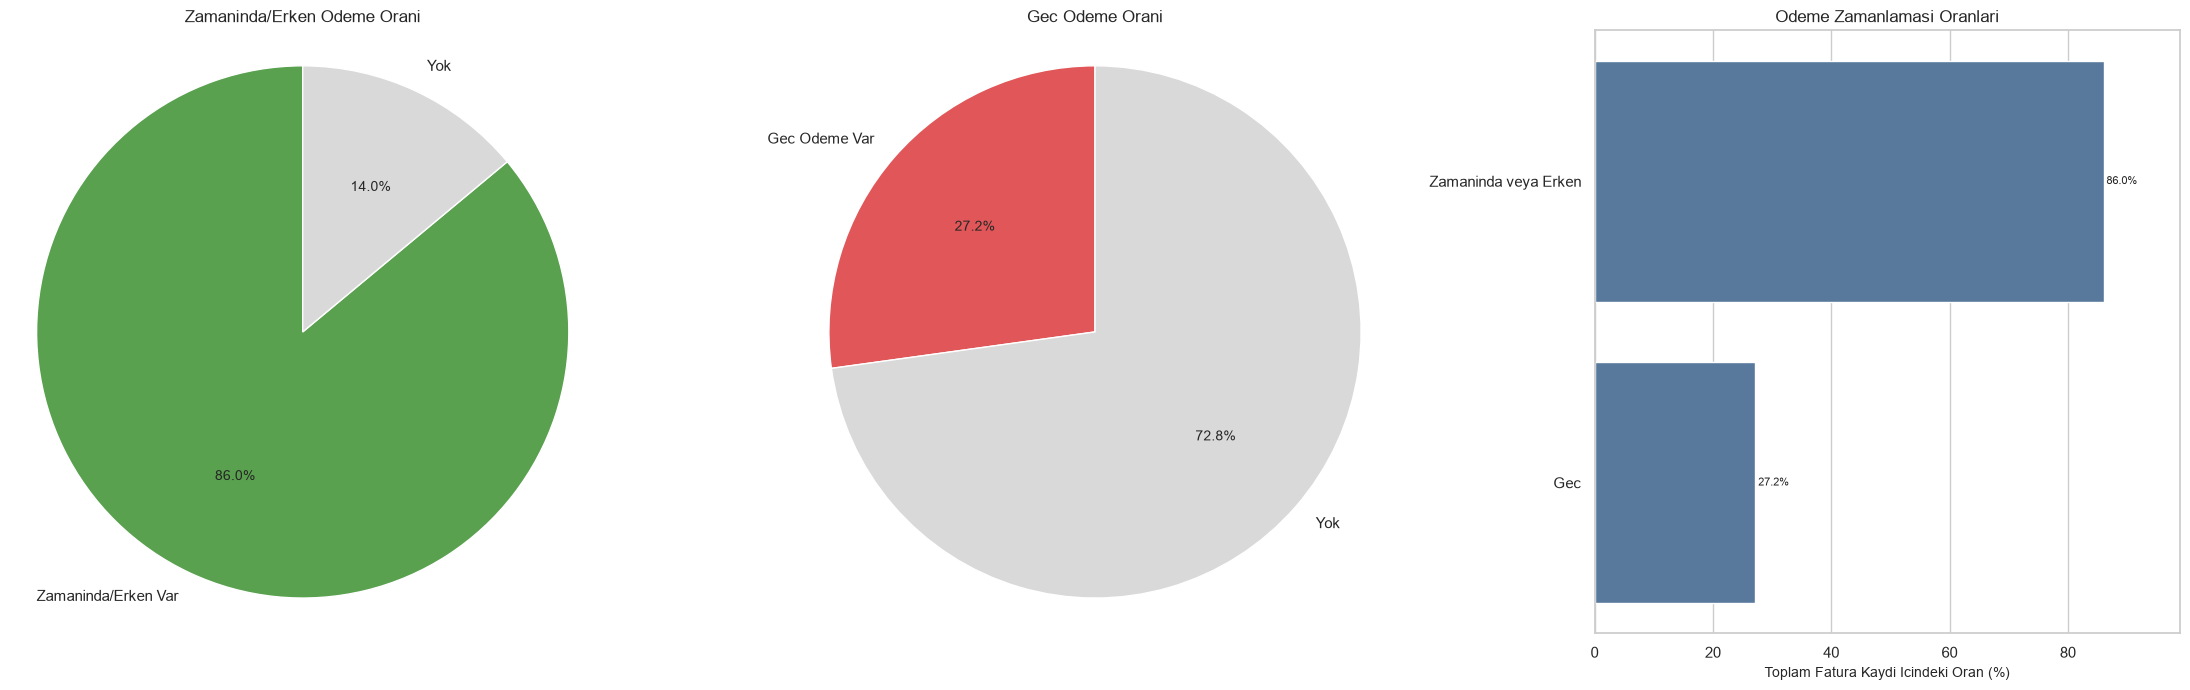

In [34]:
toplam_fatura_kaydi = len(df_tahsilat_1_clean)
zamaninda_kayit_sayisi = df_tahsilat_1_clean["zamaninda_kayit"].sum()
gec_kayit_sayisi = df_tahsilat_1_clean["gec_kayit"].sum()

odeme_ozeti = pd.DataFrame({
    "Odeme Zamanlamasi": ["Zamaninda veya Erken", "Gec"],
    "Kayit Sayisi": [zamaninda_kayit_sayisi, gec_kayit_sayisi],
    "Oran (%)": [
        zamaninda_kayit_sayisi / toplam_fatura_kaydi * 100,
        gec_kayit_sayisi / toplam_fatura_kaydi * 100,
    ],
})

display(odeme_ozeti)
print("Not: Kismi odemeler nedeniyle oranlarin toplami 100 olmak zorunda degildir.")

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

zamaninda_pie = pd.Series({"Zamaninda/Erken Var": zamaninda_kayit_sayisi, "Yok": toplam_fatura_kaydi - zamaninda_kayit_sayisi})
axes[0].pie(zamaninda_pie.values, labels=zamaninda_pie.index, autopct="%1.1f%%", startangle=90, colors=["#59A14F", "#D9D9D9"])
axes[0].set_title("Zamaninda/Erken Odeme Orani")
axes[0].axis("equal")

gec_pie = pd.Series({"Gec Odeme Var": gec_kayit_sayisi, "Yok": toplam_fatura_kaydi - gec_kayit_sayisi})
axes[1].pie(gec_pie.values, labels=gec_pie.index, autopct="%1.1f%%", startangle=90, colors=["#E15759", "#D9D9D9"])
axes[1].set_title("Gec Odeme Orani")
axes[1].axis("equal")

sns.barplot(data=odeme_ozeti, x="Oran (%)", y="Odeme Zamanlamasi", ax=axes[2], color="#4C78A8")
axes[2].set_title("Odeme Zamanlamasi Oranlari")
axes[2].set_xlabel("Toplam Fatura Kaydi Icindeki Oran (%)")
axes[2].set_ylabel("")
axes[2].set_xlim(0, max(odeme_ozeti["Oran (%)"].max() * 1.15, 10))
add_bar_labels(axes[2], odeme_ozeti["Oran (%)"].values)

plt.tight_layout(w_pad=3)
plt.savefig(FIGURES_DIR / "odeme_zamanlamasi_panel.png", dpi=150, bbox_inches="tight")
plt.show()


### Odeme Zamanlamasi Yorumu

- Odeme zamanlamasi case dokumanindaki referansla uyumlu olarak kayit bazinda hesaplanmistir.
- Ciktiya gore 917,632 fatura kaydinin 789,588 tanesinde zamaninda veya erken odeme bulunmaktadir. Bu oran yaklasik %86.0'dir.
- Gec odeme bulunan kayit sayisi 249,487'dir ve toplam fatura kayitlarinin yaklasik %27.2'sine karsilik gelir.
- Bu iki oran toplandiginda %100'u asabilir; cunku bazi kayitlarda kismi odeme nedeniyle hem zamaninda/erken hem de gec odeme tutari bulunabilir.
- Bu nedenle odeme zamanlamasi yorumlanirken "zamaninda odeme var mi" ve "gec odeme var mi" sorulari ayri ayri degerlendirilmelidir.


## 7. Iliski Analizi

Tuketim ile fatura/tahsilat degiskenleri arasindaki iliskiler scatter plot, korelasyon matrisi ve pair plot ile incelenir.


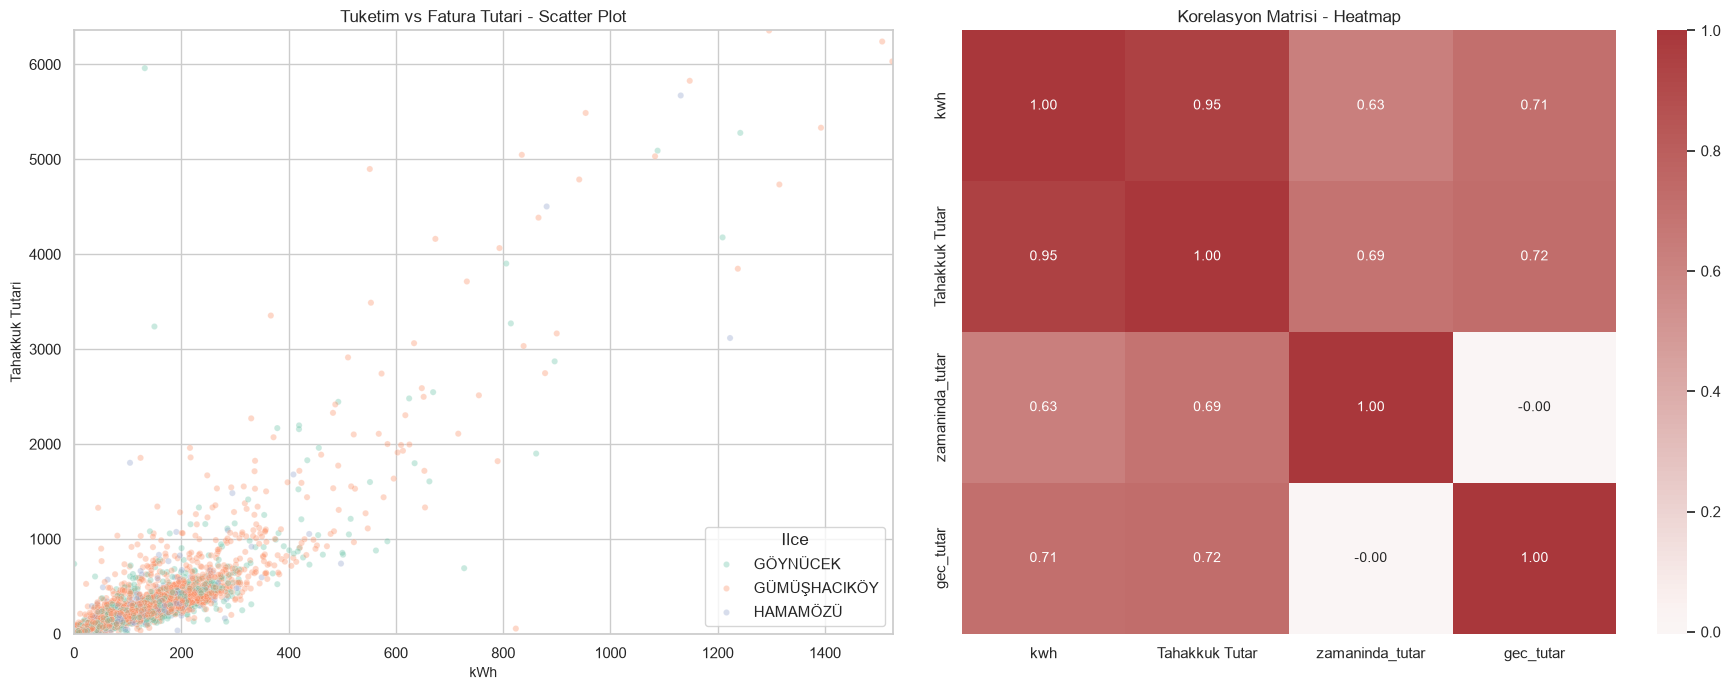

Birlesen iliski veri boyutu: (481589, 7)


In [35]:
# Tuketim ve fatura tutarini sozlesme + donem seviyesinde birlestirme.
tuketim_musteri_donem = (
    df_tahakkuk_all.groupby(["sozlesme_hesap_no", "donem", "ilce"], as_index=False)["kwh"]
    .sum()
)

fatura_musteri_donem = (
    df_tahsilat_1_clean.groupby([df_tahsilat_1_clean.columns[3], "donem"], as_index=False)
    .agg({
        tahakkuk_tutar_col: "sum",
        "zamaninda_tutar": "sum",
        "gec_tutar": "sum",
    })
    .rename(columns={df_tahsilat_1_clean.columns[3]: "sozlesme_hesap_no"})
)

iliski_df = tuketim_musteri_donem.merge(
    fatura_musteri_donem,
    on=["sozlesme_hesap_no", "donem"],
    how="inner",
)

sample_df = iliski_df.sample(n=min(5000, len(iliski_df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.scatterplot(
    data=sample_df,
    x="kwh",
    y=tahakkuk_tutar_col,
    hue="ilce",
    alpha=0.35,
    s=20,
    ax=axes[0],
)
axes[0].set_title("Tuketim vs Fatura Tutari - Scatter Plot")
axes[0].set_xlabel("kWh")
axes[0].set_ylabel("Tahakkuk Tutari")
axes[0].set_xlim(0, sample_df["kwh"].quantile(0.99))
axes[0].set_ylim(0, sample_df[tahakkuk_tutar_col].quantile(0.99))
axes[0].legend(title="Ilce")

corr_cols = ["kwh", tahakkuk_tutar_col, "zamaninda_tutar", "gec_tutar"]
corr = iliski_df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=axes[1])
axes[1].set_title("Korelasyon Matrisi - Heatmap")

plt.tight_layout(w_pad=3)
plt.savefig(FIGURES_DIR / "iliski_analizi_scatter_korelasyon.png", dpi=150, bbox_inches="tight")
plt.show()

print("Birlesen iliski veri boyutu:", iliski_df.shape)


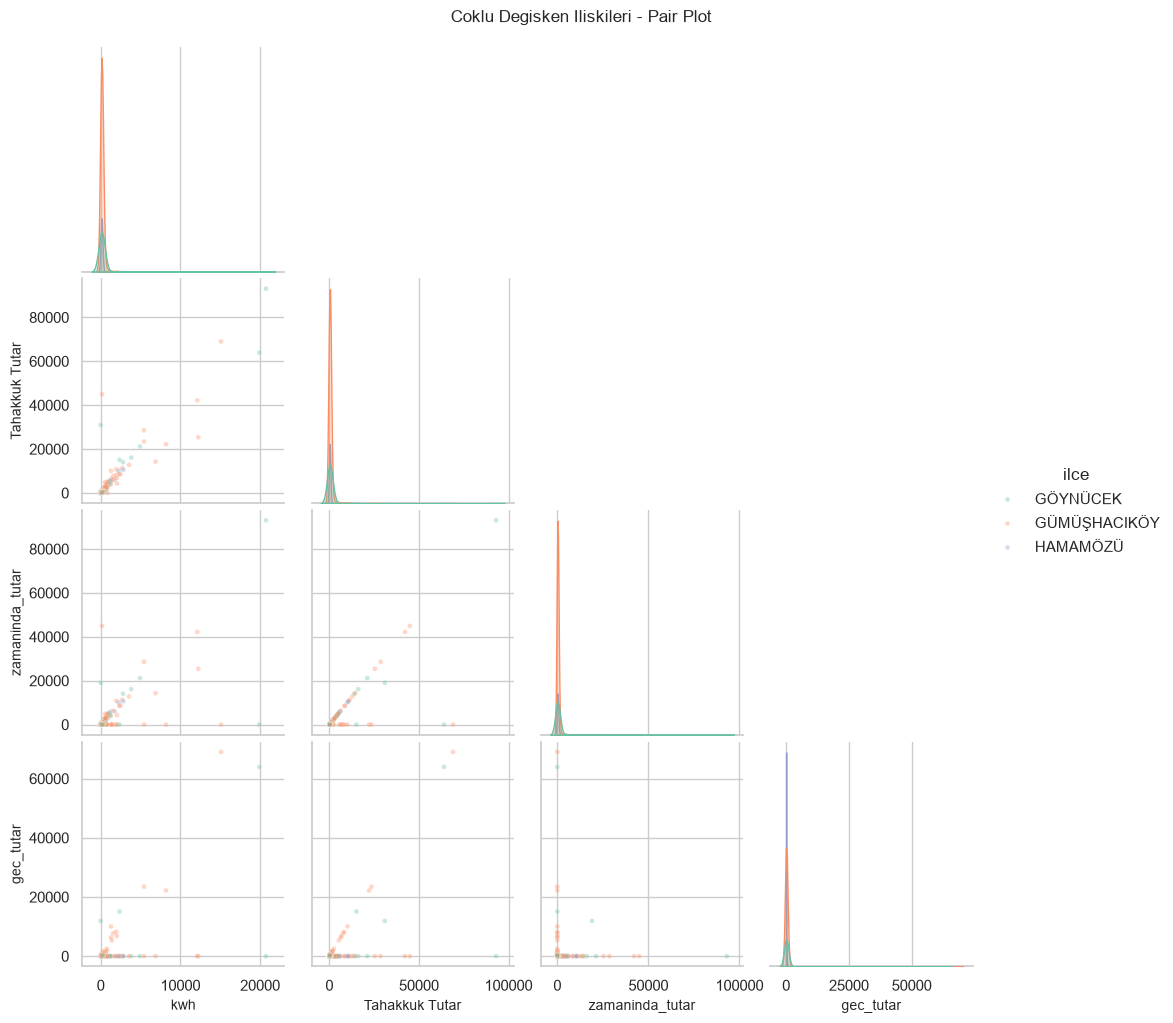

In [36]:
# Pair plot cok agir olmamasi icin orneklem uzerinden olusturulur.
pair_sample = iliski_df[corr_cols + ["ilce"]].sample(n=min(2000, len(iliski_df)), random_state=42)
pair_grid = sns.pairplot(pair_sample, vars=corr_cols, hue="ilce", corner=True, plot_kws={"alpha": 0.35, "s": 12})
pair_grid.fig.suptitle("Coklu Degisken Iliskileri - Pair Plot", y=1.02)
pair_grid.savefig(FIGURES_DIR / "pairplot_coklu_degisken.png", dpi=150, bbox_inches="tight")
plt.show()


### Iliski Analizi Yorumu

- Scatter plot, tuketim (kWh) ile tahakkuk tutari arasinda genel olarak pozitif bir iliski beklenebilecegini gosterir: tuketim arttikca fatura tutari da artma egilimindedir.
- Ancak iliski tamamen tek cizgisel degildir; tarife, hesap sinifi, donemsel farklar ve aykiri tuketimler bu iliskiyi dagitabilir.
- Korelasyon matrisi sayisal degiskenler arasindaki dogrusal iliskiyi ozetler. Yuksek korelasyonlar birlikte hareket eden degiskenleri, dusuk korelasyonlar ise daha zayif iliskileri gosterir.
- Pair plot orneklem uzerinden uretilmistir; bu nedenle tum veri setinin birebir resmi degil, coklu degisken iliskilerini hizli okumak icin kullanilan temsil edici bir gorseldir.
- Iliski analizi sozlesme-donem seviyesinde birlestirilmis veri uzerinden yapildigi icin, yorumlar tekil tahsilat satiri yerine musteri-donem davranisi seviyesinde ele alinmalidir.


## 8. Genel Degerlendirme

- Notebook 02, case dokumaninda verilen grafik onerilerini kapsayacak sekilde genisletilmistir: bar chart, pie chart, histogram, box plot, line chart, multi-line chart, stacked area, grouped bar, heatmap, stacked bar, scatter plot, korelasyon heatmap ve pair plot olusturulmustur.
- Grafikler, yalnizca gorsel uretmek icin degil, tuketim davranisi, musteri hacmi, odeme zamanlamasi ve tahsilat kanallari arasindaki farklari okumak icin kullanilmistir.
- En temel bulgu, veri setinde Mesken kayitlarinin sayisal olarak baskin olmasidir. Buna karsin yuksek ortalama tuketim daha cok sanayi, altyapi, tarimsal faaliyet ve uretici gruplarinda yogunlasmaktadir.
- Gumushacikoy musteri ve kayit hacmi acisindan en buyuk ilcedir; bu nedenle toplam degerler yorumlanirken ilce buyuklugu etkisi dikkate alinmalidir.
- Odeme zamanlamasi case referansiyla uyumlu olarak kayit bazinda hesaplanmis ve zamaninda/erken odeme oraninin yaklasik %86, gec odeme oraninin ise yaklasik %27.2 oldugu gosterilmistir.
- Grafikler `outputs/figures` klasorune kaydedilmistir ve Notebook 03'te veri hikayesi ve is onerileri olusturmak icin temel girdi olarak kullanilabilir.
